In [42]:
import pandas as pd
df = pd.read_csv(r'C:\Users\harsh\.cache\kagglehub\datasets\becksddf\churn-in-telecoms-dataset\versions\1\bigml_59c28831336c6604c800002a.csv')  # adjust path if needed
df['churn'] = df['churn'].astype(int)
df = df.drop('phone number', axis=1)
df.groupby('international plan')['churn'].mean()
df.groupby('voice mail plan')['churn'].mean()



print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['churn'].value_counts())     # confirm exact column name/values
print(df['state'].nunique())

df.groupby('churn').mean(numeric_only=True)
  # confirm cardinality

(3333, 20)
state                         str
account length              int64
area code                   int64
international plan            str
voice mail plan               str
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                       int64
dtype: object
state                     0
account length            0
area code                 0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
churn,,,,,,,,,,,,,,,,
0,100.793684,437.074737,8.604561,175.175754,100.283158,29.780421,199.043298,100.038596,16.918909,200.133193,100.058246,9.006074,10.158877,4.532982,2.743404,1.449825
1,102.664596,437.817805,5.115942,206.914079,101.335404,35.175921,212.410145,100.561077,18.054969,205.231677,100.399586,9.235528,10.700000,4.163561,2.889545,2.229814


In [43]:
df.groupby('international plan')['churn'].mean()

international plan
no     0.114950
yes    0.424149
Name: churn, dtype: float64

In [44]:
df.groupby('voice mail plan')['churn'].mean()

voice mail plan
no     0.167151
yes    0.086768
Name: churn, dtype: float64

In [45]:
df.groupby('state')['churn'].mean().sort_values(ascending=False)

state
CA    0.264706
NJ    0.264706
TX    0.250000
MD    0.242857
SC    0.233333
MI    0.219178
MS    0.215385
WA    0.212121
NV    0.212121
ME    0.209677
MT    0.205882
AR    0.200000
KS    0.185714
NY    0.180723
MN    0.178571
PA    0.177778
MA    0.169231
CT    0.162162
NC    0.161765
NH    0.160714
GA    0.148148
OK    0.147541
DE    0.147541
OR    0.141026
UT    0.138889
CO    0.136364
KY    0.135593
SD    0.133333
OH    0.128205
FL    0.126984
IN    0.126761
ID    0.123288
WY    0.116883
MO    0.111111
VT    0.109589
AL    0.100000
ND    0.096774
NM    0.096774
WV    0.094340
TN    0.094340
DC    0.092593
RI    0.092308
WI    0.089744
IL    0.086207
NE    0.081967
LA    0.078431
IA    0.068182
VA    0.064935
AZ    0.062500
AK    0.057692
HI    0.056604
Name: churn, dtype: float64

In [46]:
df['state'].value_counts().sort_values()

state
CA     34
IA     44
PA     45
LA     51
AK     52
TN     53
HI     53
DC     54
GA     54
AR     55
NH     56
IL     58
KY     59
SD     60
SC     60
DE     61
NE     61
OK     61
NM     62
ME     62
ND     62
MO     63
FL     63
AZ     64
RI     65
MA     65
MS     65
CO     66
NV     66
WA     66
NJ     68
MT     68
NC     68
KS     70
MD     70
IN     71
TX     72
UT     72
VT     73
ID     73
MI     73
CT     74
VA     77
WY     77
OR     78
WI     78
OH     78
AL     80
NY     83
MN     84
WV    106
Name: count, dtype: int64

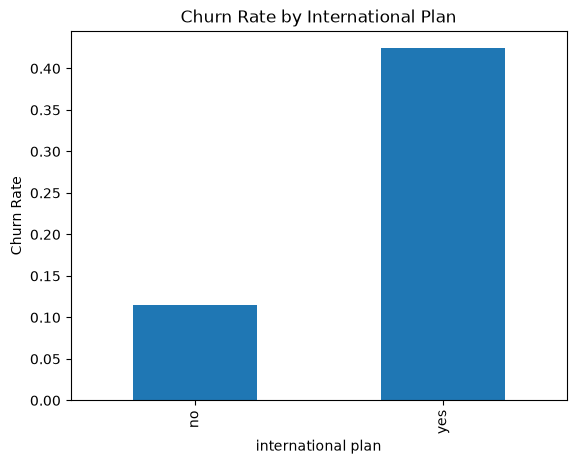

In [47]:
import matplotlib.pyplot as plt

df.groupby('international plan')['churn'].mean().plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by International Plan')
plt.show()

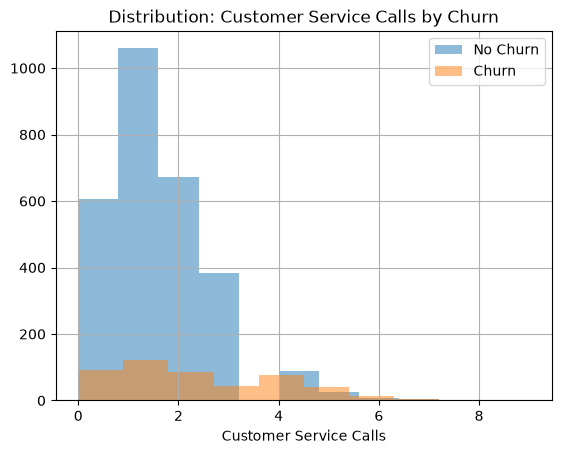

In [48]:
df[df['churn']==0]['customer service calls'].hist(alpha=0.5, label='No Churn', bins=10)
df[df['churn']==1]['customer service calls'].hist(alpha=0.5, label='Churn', bins=10)
plt.legend()
plt.xlabel('Customer Service Calls')
plt.title('Distribution: Customer Service Calls by Churn')
plt.show()

In [49]:
df.corr(numeric_only=True)

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
account length,1.000000,-0.012463,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796,0.016541
area code,-0.012463,1.000000,-0.001994,-0.008264,-0.009646,-0.008264,0.003580,-0.011886,0.003607,-0.005825,0.016522,-0.005845,-0.018288,-0.024179,-0.018395,0.027572,0.006174
number vmail messages,-0.004628,-0.001994,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263,-0.089728
total day minutes,0.006216,-0.008264,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423,0.205151
total day calls,0.038470,-0.009646,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942,0.018459
total day charge,0.006214,-0.008264,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427,0.205151
total eve minutes,-0.006757,0.003580,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985,0.092796
total eve calls,0.019260,-0.011886,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423,0.009233
total eve charge,-0.006745,0.003607,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987,0.092786
total night minutes,-0.008955,-0.005825,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288,0.035493


In [50]:
import numpy as np

# Simulate: if the true churn rate is 14.5% everywhere,
# how often would a random sample of 34 people show 26%+ churn just by luck?
np.random.seed(42)
overall_rate = df['churn'].mean()
simulated_rates = [np.random.binomial(34, overall_rate) / 34 for _ in range(10000)]
print("How often random 34-person samples hit 26%+ churn:", 
      np.mean(np.array(simulated_rates) >= 0.2647))

How often random 34-person samples hit 26%+ churn: 0.0453


In [51]:

df = df.drop(['state', 'total day minutes', 'total eve minutes', 'total night minutes', 'total intl minutes'], axis=1)

In [52]:
print(df.columns.tolist())

['account length', 'area code', 'international plan', 'voice mail plan', 'number vmail messages', 'total day calls', 'total day charge', 'total eve calls', 'total eve charge', 'total night calls', 'total night charge', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']


In [53]:
df['international plan'] = (df['international plan'] == 'yes').astype(int)
df['voice mail plan'] = (df['voice mail plan'] == 'yes').astype(int)

In [54]:
print(df[['international plan','voice mail plan']].dtypes)
print(df['international plan'].value_counts())

international plan    int64
voice mail plan       int64
dtype: object
international plan
0    3010
1     323
Name: count, dtype: int64


In [55]:
df['high_service_calls'] = (df['customer service calls'] >= 4).astype(int)
print(df['high_service_calls'].value_counts())

high_service_calls
0    3066
1     267
Name: count, dtype: int64


In [56]:
df.groupby('high_service_calls')['churn'].mean()

high_service_calls
0    0.112524
1    0.516854
Name: churn, dtype: float64

In [57]:
print(df.shape)
print(df.columns.tolist())

(3333, 16)
['account length', 'area code', 'international plan', 'voice mail plan', 'number vmail messages', 'total day calls', 'total day charge', 'total eve calls', 'total eve charge', 'total night calls', 'total night charge', 'total intl calls', 'total intl charge', 'customer service calls', 'churn', 'high_service_calls']


In [58]:
X = df.drop('churn' , axis = 1)
y = df["churn"]

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [60]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(y_train.mean(), y_test.mean())

(2666, 15) (667, 15) (2666,) (667,)
0.1447861965491373 0.1454272863568216


In [61]:
"model training through logistic regression"
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\harsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
from sklearn.preprocessing import StandardScaler


scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)



In [63]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [64]:
from sklearn.metrics import classification_report, confusion_matrix
model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91       570
           1       0.49      0.86      0.63        97

    accuracy                           0.85       667
   macro avg       0.73      0.85      0.77       667
weighted avg       0.90      0.85      0.87       667

[[485  85]
 [ 14  83]]


In [65]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature' : X.columns,
    'coefficient' : model_balanced.coef_[0]

}).sort_values('coefficient', ascending=False)

print(coefficients)

                   feature  coefficient
14      high_service_calls     0.998476
6         total day charge     0.825501
2       international plan     0.748715
4    number vmail messages     0.703147
8         total eve charge     0.452182
12       total intl charge     0.206812
10      total night charge     0.169416
0           account length     0.101833
7          total eve calls     0.050773
13  customer service calls     0.049973
9        total night calls     0.048706
5          total day calls     0.012310
1                area code    -0.055840
11        total intl calls    -0.168612
3          voice mail plan    -1.076364


In [66]:
df[['number vmail messages', 'voice mail plan']].corr()

,number vmail messages,voice mail plan
number vmail messages,1.000000,0.956927
voice mail plan,0.956927,1.000000


In [67]:
X = X.drop('number vmail messages', axis=1)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [69]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [70]:
print(len(X.columns))
print(model_balanced.coef_[0].shape)
print(X_train_scaled.shape)

14
(15,)
(2666, 14)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_balanced = LogisticRegression(class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coefficients)
print(classification_report(y_test, y_pred_balanced))

                   feature  coefficient
13      high_service_calls     0.990569
5         total day charge     0.826840
2       international plan     0.748805
7         total eve charge     0.447919
11       total intl charge     0.208102
9       total night charge     0.169719
0           account length     0.101963
12  customer service calls     0.060544
6          total eve calls     0.047690
8        total night calls     0.036863
4          total day calls     0.013904
1                area code    -0.050247
10        total intl calls    -0.171668
3          voice mail plan    -0.377188
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       570
           1       0.49      0.86      0.63        97

    accuracy                           0.85       667
   macro avg       0.73      0.85      0.77       667
weighted avg       0.90      0.85      0.87       667



In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight= 'balanced' , random_state = 42)
rf_model.fit(X_train_scaled,y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       570
           1       0.74      0.76      0.75        97

    accuracy                           0.93       667
   macro avg       0.85      0.86      0.85       667
weighted avg       0.93      0.93      0.93       667

[[544  26]
 [ 23  74]]


In [73]:
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
print(y_proba_rf[:10])  # print first 10 predicted probabilities

[0.72 0.01 0.13 0.09 0.12 0.09 0.08 0.01 0.15 0.07]


In [74]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Look at a few specific points to compare
import pandas as pd
pr_table = pd.DataFrame({'threshold': thresholds, 'precision': precisions[:-1], 'recall': recalls[:-1]})
print(pr_table[pr_table['threshold'].between(0.2, 0.5)].iloc[::5])  # sample every 5th row in this range

    threshold  precision    recall
20       0.20   0.412060  0.845361
25       0.25   0.490909  0.835052
30       0.30   0.563380  0.824742
35       0.35   0.615385  0.824742
40       0.41   0.683761  0.824742
45       0.47   0.722222  0.804124


In [75]:
choosen_threshold = 0.3
y_pred_tuned = (y_proba_rf >= choosen_threshold).astype(int)

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       570
           1       0.56      0.82      0.67        97

    accuracy                           0.88       667
   macro avg       0.77      0.86      0.80       667
weighted avg       0.91      0.88      0.89       667

[[508  62]
 [ 17  80]]


In [76]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's equivalent of class_weight='balanced'
# it's the ratio of negative to positive class counts
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       570
           1       0.81      0.75      0.78        97

    accuracy                           0.94       667
   macro avg       0.88      0.86      0.87       667
weighted avg       0.94      0.94      0.94       667

[[553  17]
 [ 24  73]]


In [77]:
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)

pr_table_xgb = pd.DataFrame({'threshold': thresholds_xgb, 'precision': precisions_xgb[:-1], 'recall': recalls_xgb[:-1]})
print(pr_table_xgb[pr_table_xgb['threshold'].between(0.2, 0.5)].iloc[::5])

     threshold  precision    recall
558   0.209981   0.706422  0.793814
563   0.263255   0.721154  0.773196
568   0.329930   0.757576  0.773196
573   0.459998   0.797872  0.773196


In [78]:
chosen_threshold_xgb = 0.21
y_pred_xgb_tuned = (y_proba_xgb >= chosen_threshold_xgb).astype(int)

print(classification_report(y_test, y_pred_xgb_tuned))
print(confusion_matrix(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       570
           1       0.71      0.79      0.75        97

    accuracy                           0.92       667
   macro avg       0.84      0.87      0.85       667
weighted avg       0.93      0.92      0.93       667

[[539  31]
 [ 20  77]]


In [79]:
'saving the xgboost one with threshold 0.21 as the final model'

import joblib

joblib.dump(xgb_model, 'churn_model_xgb.pkl')
joblib.dump(scaler,'churn_scaler.pkl')

#save the choosen threshold
import json
with open('model_config.json','w')as f:
    json.dump({'threshold': 0.21,'model':'XGBoost','features':list(X.columns)}, f)

print("Model, scaler, and configuration saved successfully.")

Model, scaler, and configuration saved successfully.


In [80]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance':xgb_model.feature_importances_
}).sort_values('importance' , ascending = False)

print(importances)

                   feature  importance
2       international plan    0.311342
12  customer service calls    0.167773
3          voice mail plan    0.116498
5         total day charge    0.089587
11       total intl charge    0.050576
7         total eve charge    0.048108
10        total intl calls    0.045869
0           account length    0.039226
9       total night charge    0.034444
8        total night calls    0.030860
6          total eve calls    0.023801
4          total day calls    0.023067
1                area code    0.018848
13      high_service_calls    0.000000


In [81]:
X_no_flag = X.drop('high_service_calls', axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_flag, y, test_size=0.2, stratify=y, random_state=42)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

scale_pos_weight2 = (y_train2 == 0).sum() / (y_train2 == 1).sum()
xgb_model2 = XGBClassifier(scale_pos_weight=scale_pos_weight2, random_state=42, eval_metric='logloss')
xgb_model2.fit(X_train2_scaled, y_train2)

y_proba_xgb2 = xgb_model2.predict_proba(X_test2_scaled)[:, 1]
y_pred_xgb2_tuned = (y_proba_xgb2 >= 0.21).astype(int)

print(classification_report(y_test2, y_pred_xgb2_tuned))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       570
           1       0.71      0.79      0.75        97

    accuracy                           0.92       667
   macro avg       0.84      0.87      0.85       667
weighted avg       0.93      0.92      0.93       667



In [82]:
import joblib
import json

joblib.dump(xgb_model2,'churn_model_xgb.pkl')
joblib.dump(scaler2, 'churn_scaler.pkl')

with open('model_config.json', 'w') as f:
    json.dump({'threshold': 0.21, 'model': 'XGBoost', 'features': list(X_no_flag.columns)}, f)

print("Model, scaler, and configuration saved successfully without 'high_service_calls' feature.")


Model, scaler, and configuration saved successfully without 'high_service_calls' feature.
